In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

if os.path.exists('/kaggle/input'):
    BASE_PATH = '/kaggle/input/kepler-labelled-time-series-data/'
else:
    BASE_PATH = './' 

train_df = pd.read_csv(f'{BASE_PATH}exoTrain.csv')
test_df = pd.read_csv(f'{BASE_PATH}exoTest.csv')

x_train = np.array(train_df.iloc[:, 1:])
y_train = np.array(train_df.iloc[:, 0])

In this notebook, I compare differend CNN architectures on the Kepler 
exoplanet dataset. The goal is to correctly identify stars that have 
exoplanets based on their light curves.

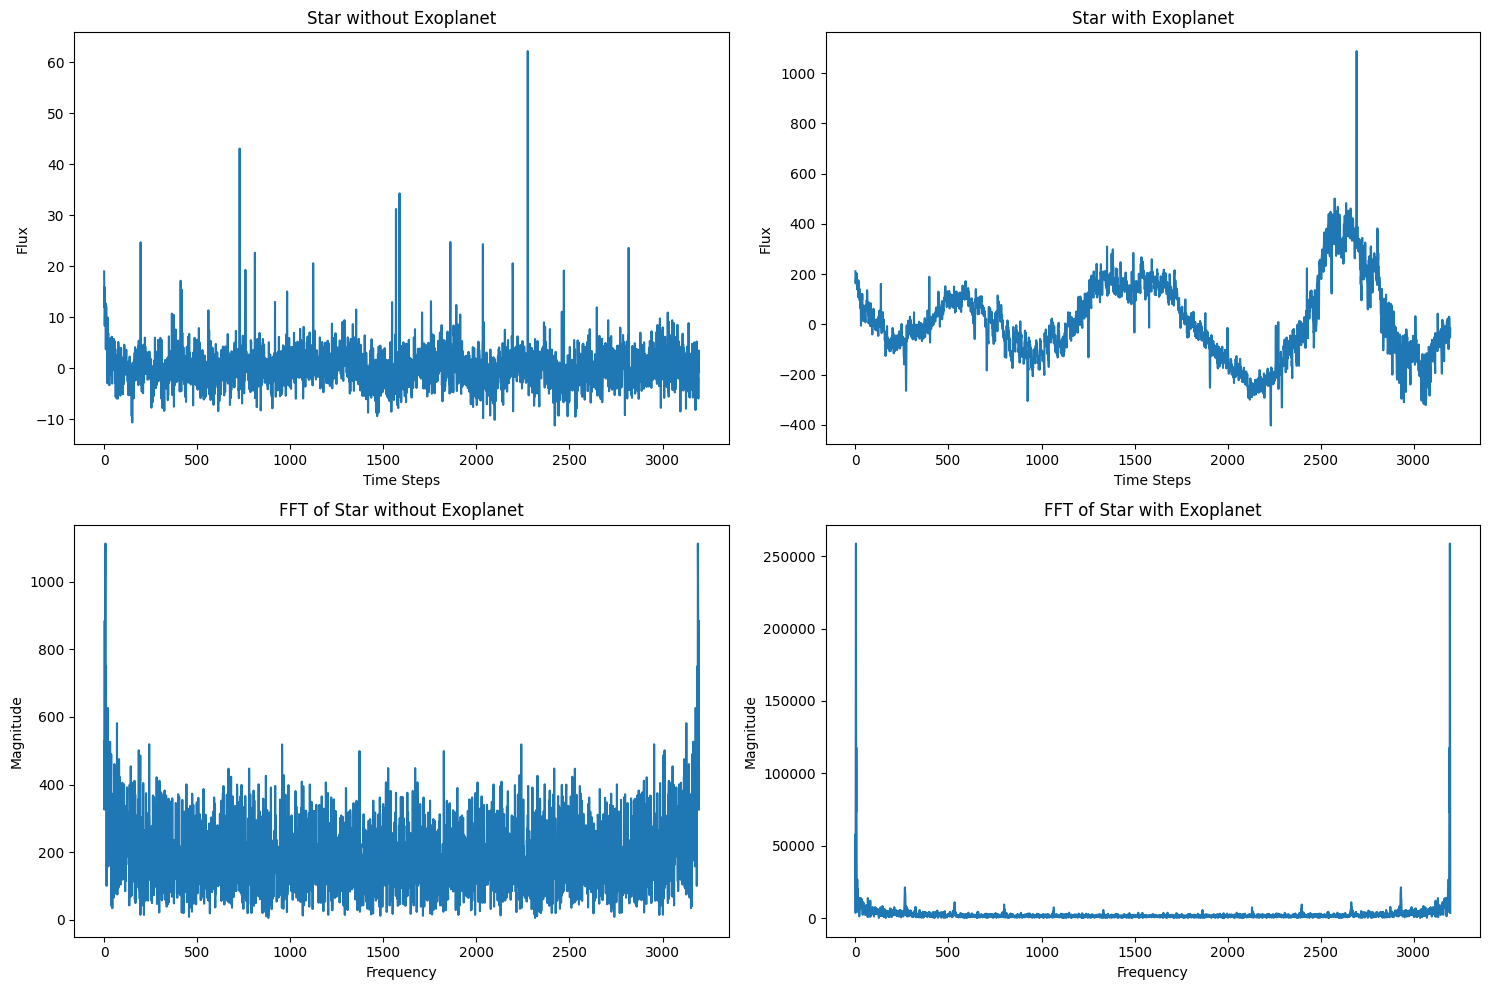

In [2]:
# Plot random examples of both classes (with and without exoplanets)
random_index_1 = np.random.choice(np.where(y_train == 1)[0])
random_index_2 = np.random.choice(np.where(y_train == 2)[0])

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

ax1.plot(x_train[random_index_1])
ax1.set_title('Star without Exoplanet')
ax1.set_xlabel('Time Steps')
ax1.set_ylabel('Flux')

ax2.plot(x_train[random_index_2])
ax2.set_title('Star with Exoplanet')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Flux')

fft_1 = np.fft.fft(x_train[random_index_1])
fft_2 = np.fft.fft(x_train[random_index_2])

ax3.plot(np.abs(fft_1))
ax3.set_title('FFT of Star without Exoplanet')
ax3.set_xlabel('Frequency')
ax3.set_ylabel('Magnitude')

ax4.plot(np.abs(fft_2))
ax4.set_title('FFT of Star with Exoplanet')
ax4.set_xlabel('Frequency')
ax4.set_ylabel('Magnitude')

plt.tight_layout()

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
from tqdm.auto import tqdm
from ExoPlanetModels import KeplerDataset, DualStreamModel, RawOnlyModel, FFTOnlyModel, LargeResNetModel

In [21]:
def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for x_raw, x_fft, y in data_loader:
            x_raw, x_fft, y = x_raw.to(device), x_fft.to(device), y.to(device)
            outputs = model(x_raw, x_fft)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def train_model(model, model_name, epochs=30, lr=0.0001, batch_size=32):
    train_ds = KeplerDataset(f'{BASE_PATH}exoTrain.csv')
    test_ds = KeplerDataset(f'{BASE_PATH}exoTest.csv')
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        device_name = "MPS"
    else:
        device = torch.device("cpu")
        device_name = "CPU"
    
    model = model.to(device)
    
    pos_weight = torch.tensor([5000 / 37]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.3)

    loss_history = []
    
    print(f"\n{model_name} | Device: {device_name}")
    print("-" * 50)
    
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for x_raw, x_fft, y in train_loader:
            x_raw, x_fft, y = x_raw.to(device), x_fft.to(device), y.to(device)
            
            optimizer.zero_grad()
            outputs = model(x_raw, x_fft)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        
        current_lr = optimizer.param_groups[0]['lr']
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | LR: {current_lr:.6f}")
        scheduler.step()
    
    y_train, pred_train, prob_train = evaluate_model(model, train_loader, device)
    y_test, pred_test, prob_test = evaluate_model(model, test_loader, device)
    
    train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(y_train, pred_train, average='binary', zero_division=0)
    test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(y_test, pred_test, average='binary', zero_division=0)
    train_roc_auc = roc_auc_score(y_train, prob_train)
    test_roc_auc = roc_auc_score(y_test, prob_test)
    
    print(f"\nTrain | Precision: {train_precision:.3f} | Recall: {train_recall:.3f} | F1: {train_f1:.3f} | ROC-AUC: {train_roc_auc:.3f}")
    print(f"Test  | Precision: {test_precision:.3f} | Recall: {test_recall:.3f} | F1: {test_f1:.3f} | ROC-AUC: {test_roc_auc:.3f}")
    
    return model, loss_history, {
        'train': {'precision': train_precision, 'recall': train_recall, 'f1': train_f1, 'roc_auc': train_roc_auc},
        'test': {'precision': test_precision, 'recall': test_recall, 'f1': test_f1, 'roc_auc': test_roc_auc}
    }


Dual-Stream | Device: MPS
--------------------------------------------------
Epoch  1/30 | Loss: 1.6992 | LR: 0.000100
Epoch 10/30 | Loss: 0.3652 | LR: 0.000100
Epoch 20/30 | Loss: 0.3845 | LR: 0.000030
Epoch 30/30 | Loss: 0.3350 | LR: 0.000009

Train | Precision: 0.627 | Recall: 1.000 | F1: 0.771 | ROC-AUC: 1.000
Test  | Precision: 0.600 | Recall: 0.600 | F1: 0.600 | ROC-AUC: 0.995

Raw-Only | Device: MPS
--------------------------------------------------
Epoch  1/30 | Loss: 1.6742 | LR: 0.000100
Epoch 10/30 | Loss: 0.3134 | LR: 0.000100
Epoch 20/30 | Loss: 0.1583 | LR: 0.000030
Epoch 30/30 | Loss: 0.1264 | LR: 0.000009

Train | Precision: 0.398 | Recall: 1.000 | F1: 0.569 | ROC-AUC: 1.000
Test  | Precision: 0.333 | Recall: 0.600 | F1: 0.429 | ROC-AUC: 0.984

FFT-Only | Device: MPS
--------------------------------------------------
Epoch  1/30 | Loss: 1.3614 | LR: 0.000100
Epoch 10/30 | Loss: 0.1837 | LR: 0.000100
Epoch 20/30 | Loss: 0.1098 | LR: 0.000030
Epoch 30/30 | Loss: 0.0975 |

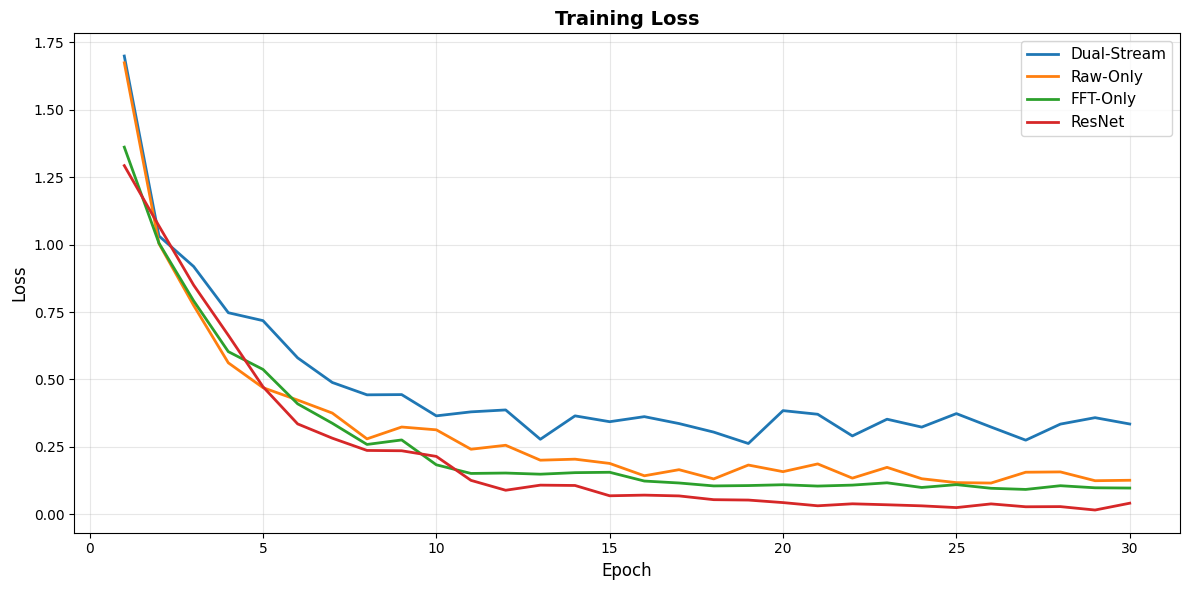


Model                Test F1      Test Recall     Test ROC-AUC   
Dual-Stream          0.600        0.600           0.995          
Raw-Only             0.429        0.600           0.984          
FFT-Only             0.375        0.600           0.982          
ResNet               0.769        1.000           1.000          


In [24]:
dual_stream_model = DualStreamModel()
raw_only_model = RawOnlyModel()
fft_only_model = FFTOnlyModel()
resnet_model = LargeResNetModel()

models = [
    ("Dual-Stream", dual_stream_model),
    ("Raw-Only", raw_only_model),
    ("FFT-Only", fft_only_model),
    ("ResNet", resnet_model)
]

results = {}
for name, model in models:
    trained_model, loss_history, metrics = train_model(model, name)
    results[name] = {
        "model": trained_model,
        "loss": loss_history,
        "metrics": metrics
    }

plt.figure(figsize=(12, 6))
for name, data in results.items():
    epochs_range = range(1, len(data["loss"]) + 1)
    plt.plot(epochs_range, data["loss"], linewidth=2, label=name)

plt.title('Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(f"{'Model':<20} {'Test F1':<12} {'Test Recall':<15} {'Test ROC-AUC':<15}")
print("="*70)
for name, data in results.items():
    test_metrics = data["metrics"]["test"]
    print(f"{name:<20} {test_metrics['f1']:<12.3f} {test_metrics['recall']:<15.3f} {test_metrics['roc_auc']:<15.3f}")
print("="*70)